## Notebook Summary

This notebook presents implementations of kalman, extended kalman, and unscented kalman filters applied to the motion of a simple pendulum. This system exemplifies how linearization (Kalman) breaks down at large angle arguments, justifying the use of nonlinear extensions of the kalman filter, ekf and ukf.

In [1]:
# Imports

import numpy as np
import matplotlib.pyplot as plt

%matplotlib widget

In [2]:
# Simulation parameters

# System params
G = 9.81        # gravity accel metric
L = 0.5         # Pendulum length m
T = 5           # total simulation duration
fs = 5000         # sample rate, Hz
theta_0_small = np.deg2rad(10.0)   # initial angle, small, rad
theta_0_large = np.deg2rad(60.0)   # initial angle, large, rad
theta_dot_0 = 0.0      # initial angular velocity (at rest), rad/s

# Noise params
Q = np.diag([0.001, 0.001])   # process noise covariance
R = 0.1                       # observation noise variance


# Helper function - pendulum f0
def get_pendulum_natural_freq(length_m):
    return 1 / (2 * np.pi) * np.sqrt(G / length_m)


# Computed from params
dt = 1 / fs

# Ensure that sampling frequency can resolve natural freq of pendulum
assert get_pendulum_natural_freq(L) < (fs /2), "Increase samplerate"

In [3]:
# Ground truth simulation

N = int(T / dt)     # total time steps
theta = np.zeros(N)
theta_dot = np.zeros(N)
theta[0] = theta_0_large      # Define initial angle theta
theta_dot[0] = theta_dot_0    

for n in range(1, N):
    theta_ddot = -(G / L) * np.sin(theta[n - 1])    # true dynamics @ time step n-1
    theta_dot[n] = theta_dot[n - 1] + theta_ddot * dt   # Euler integration
    theta[n] = theta[n - 1] + theta_dot[n - 1] * dt

# Add gaussian noise to theta to generate "observations"
z = theta + np.sqrt(R) * np.random.randn(N)

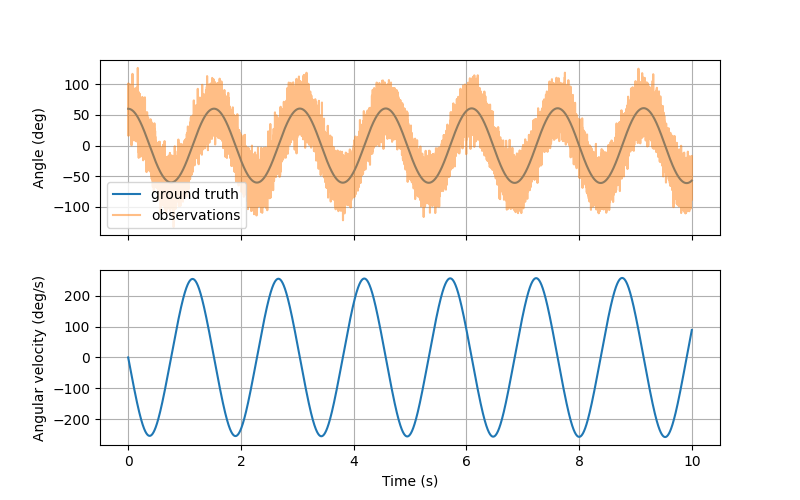

In [4]:
# Plot ground truth

plt.close('all')
t = np.arange(N) * dt

fig, axes = plt.subplots(2, 1, figsize=(8, 5), sharex=True)

axes[0].plot(t, np.rad2deg(theta), label='ground truth')
axes[0].plot(t, np.rad2deg(z), label='observations', alpha=0.5)
axes[0].set_ylabel('Angle (deg)')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(t, np.rad2deg(theta_dot))
axes[1].set_ylabel('Angular velocity (deg/s)')
axes[1].set_xlabel('Time (s)')
axes[1].grid(True)
plt.show()

## Re: Euler integration to compute ground truth

Integration with low fs eventually diverges to to energy accumulation. Samplerate increased here, which produces effectively constant amplitude over relatively small T

If longer T or low fs required, use scipy.integrate.solve_ivp with RK45